In [304]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

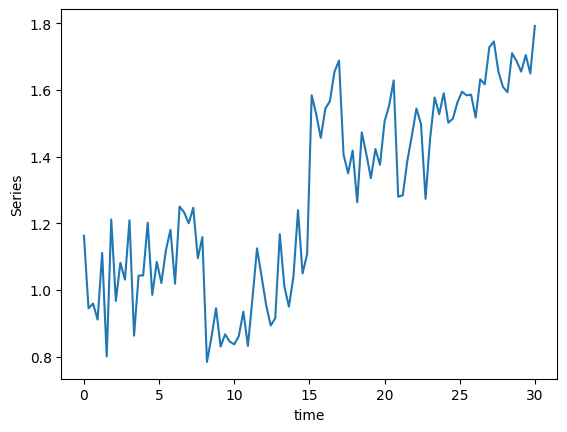

In [305]:
t = np.linspace(0,30,num=100)
np.random.seed(1)
Y = np.random.normal(0,0.1,size=t.shape)+np.exp(0.02*t)-0.3*(t>=8)+0.5*(t>=15)-0.3*(t>=17)
plt.plot(t,Y)
plt.ylabel("Series")
plt.xlabel("time")
plt.show()

In [306]:
from sklearn.preprocessing import MinMaxScaler

# split
X_train, X_test = t[:-12], t[-12:]
Y_train, Y_test = Y[:-12], Y[-12:]

# reshape
X_train = X_train.reshape(-1, 1)
X_test  = X_test.reshape(-1, 1)
Y_train = Y_train.reshape(-1, 1)
Y_test  = Y_test.reshape(-1, 1)

# scalers
x_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
y_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(Y_train)

# transform
Xtr = torch.tensor(x_scaler.transform(X_train), dtype=torch.float32)
Xte = torch.tensor(x_scaler.transform(X_test), dtype=torch.float32)

Ytr = torch.tensor(y_scaler.transform(Y_train), dtype=torch.float32)
Yte = torch.tensor(y_scaler.transform(Y_test), dtype=torch.float32)

print(Xtr.shape, Xte.shape)
print(Ytr.shape, Yte.shape)

torch.Size([88, 1]) torch.Size([12, 1])
torch.Size([88, 1]) torch.Size([12, 1])


In [307]:
torch.manual_seed(1)

model = torch.nn.Sequential(
    torch.nn.Linear(1, 10), torch.nn.Tanh(),
    torch.nn.Linear(10, 1),

)
opt = torch.optim.Adam(model.parameters(), lr=1e-2,weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

In [308]:
for epoch in range(1, 10000):
    opt.zero_grad()
    loss = loss_fn(model(Xtr), Ytr)
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        with torch.no_grad():
            te = loss_fn(model(Xte), Yte).item()
        print(f"epoch {epoch:4d} | train {loss.item():.5f} | test {te:.5f}")

epoch 1000 | train 0.06693 | test 0.02365
epoch 2000 | train 0.06546 | test 0.01950
epoch 3000 | train 0.06499 | test 0.03301
epoch 4000 | train 0.06400 | test 0.06474
epoch 5000 | train 0.06344 | test 0.07788
epoch 6000 | train 0.06295 | test 0.07157
epoch 7000 | train 0.06151 | test 0.05244
epoch 8000 | train 0.05933 | test 0.03708
epoch 9000 | train 0.05752 | test 0.03479


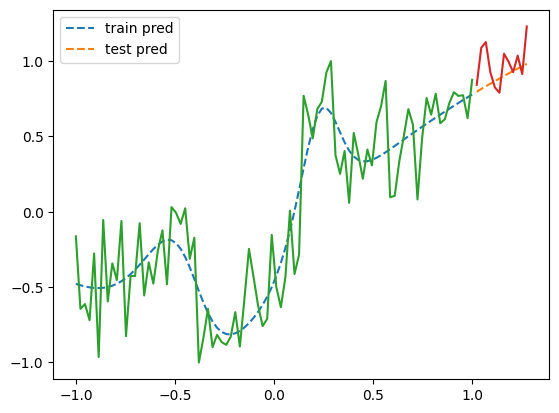

In [309]:
plt.plot(Xtr,model(Xtr).detach().numpy(),'--',label="train pred")
plt.plot(Xte,model(Xte).detach().numpy(),'--',label="test pred")
plt.plot(Xtr,Ytr)
plt.plot(Xte,Yte)

plt.legend()
plt.show()

In [310]:
L = 2  # lookback window

Y_all = torch.cat([Ytr, Yte], dim=0)

Xs, Ys = [], []
for i in range(len(Y_all) - L):
    Xs.append(Y_all[i:i+L])
    Ys.append(Y_all[i+L])

Xs = torch.stack(Xs)      # [samples, L, 1]
Ys = torch.stack(Ys)      # [samples, 1]

split = len(Ytr) - L

Xtr_seq, Xte_seq = Xs[:split], Xs[split:]
Ytr_seq, Yte_seq = Ys[:split], Ys[split:]

rnn = torch.nn.RNN(input_size=1, hidden_size=4, batch_first=True)
out = torch.nn.Linear(4, 1)

opt = torch.optim.Adam(list(rnn.parameters()) + list(out.parameters()), lr=1e-2, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

for epoch in range(5000):
    opt.zero_grad()
    h_seq, _ = rnn(Xtr_seq)
    pred = out(h_seq[:, -1, :])
    loss = loss_fn(pred, Ytr_seq)
    loss.backward()
    opt.step()

    if epoch % 200 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    htr, _ = rnn(Xtr_seq)
    rnn_train_pred = out(htr[:, -1, :])

    hte, _ = rnn(Xte_seq)
    rnn_test_pred = out(hte[:, -1, :])

# inverse transform
rnn_train_pred_np = y_scaler.inverse_transform(rnn_train_pred.numpy())
rnn_test_pred_np  = y_scaler.inverse_transform(rnn_test_pred.numpy())

Ytr_seq_np = y_scaler.inverse_transform(Ytr_seq.numpy())
Yte_seq_np = y_scaler.inverse_transform(Yte_seq.numpy())

0 0.5338388681411743
200 0.08300887793302536
400 0.08060778677463531
600 0.07947822660207748
800 0.07863600552082062
1000 0.07744257152080536
1200 0.07578588277101517
1400 0.07511173188686371
1600 0.0749349594116211
1800 0.07475968450307846
2000 0.07448367029428482
2200 0.07407506555318832
2400 0.0736122578382492
2600 0.07317037880420685
2800 0.07272747159004211
3000 0.0717616081237793
3200 0.06690693646669388
3400 0.060418859124183655
3600 0.057988714426755905
3800 0.05715629830956459
4000 0.05695585161447525
4200 0.05670826509594917
4400 0.056605737656354904
4600 0.05651267245411873
4800 0.05637524276971817


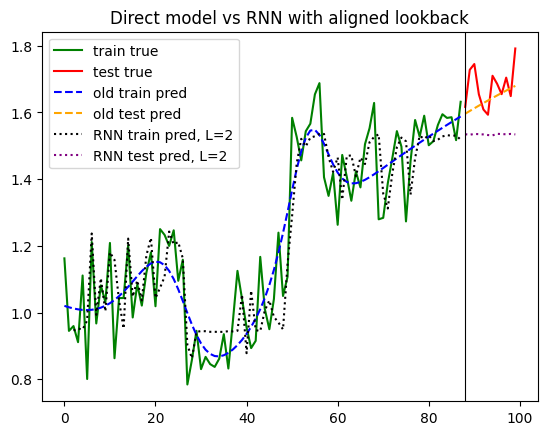

In [311]:
# old/direct model predictions, inverse-scaled if needed
with torch.no_grad():
    old_train_pred = model(Xtr).detach().numpy()
    old_test_pred  = model(Xte).detach().numpy()

# If model outputs are still scaled, inverse transform them
old_train_pred_np = y_scaler.inverse_transform(old_train_pred)
old_test_pred_np  = y_scaler.inverse_transform(old_test_pred)

Ytr_np = y_scaler.inverse_transform(Ytr.numpy())
Yte_np = y_scaler.inverse_transform(Yte.numpy())

# indices
train_idx_old = np.arange(len(Ytr_np))
test_idx_old  = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))

# RNN starts after lookback L
train_idx_rnn = np.arange(L, len(Ytr_np))
test_idx_rnn  = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))


# true series
plt.plot(train_idx_old, Ytr_np, color="green", label="train true")
plt.plot(test_idx_old, Yte_np, color="red", label="test true")

# old/direct model
plt.plot(train_idx_old, old_train_pred_np, "--", color="blue", label="old train pred")
plt.plot(test_idx_old, old_test_pred_np, "--", color="orange", label="old test pred")

# RNN model, shifted forward by L
plt.plot(train_idx_rnn, rnn_train_pred_np, ":", color="black", label=f"RNN train pred, L={L}")
plt.plot(test_idx_rnn, rnn_test_pred_np, ":", color="purple", label=f"RNN test pred, L={L}")

plt.axvline(len(Ytr_np), color="black", linewidth=0.8)
plt.legend()
plt.title("Direct model vs RNN with aligned lookback")
plt.show()

In [312]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true.ravel() - y_pred.ravel()) ** 2))

def hit_ratio(y_true, y_pred):
    """
    Directional accuracy.
    Uses changes, so it checks whether predicted direction matches actual direction.
    """
    actual_dir = np.sign(np.diff(y_true.ravel()))
    pred_dir   = np.sign(np.diff(y_pred.ravel()))
    return np.mean(actual_dir == pred_dir)

metrics_tbl = pd.DataFrame([
    {
        "model": "direct",
        "sample": "train",
        "rmse": rmse(Ytr_np, old_train_pred_np),
        "hit_ratio": hit_ratio(Ytr_np, old_train_pred_np),
    },
    {
        "model": "direct",
        "sample": "test",
        "rmse": rmse(Yte_np, old_test_pred_np),
        "hit_ratio": hit_ratio(Yte_np, old_test_pred_np),
    },
    {
        "model": "RNN",
        "sample": "train",
        "rmse": rmse(Ytr_seq_np, rnn_train_pred_np),
        "hit_ratio": hit_ratio(Ytr_seq_np, rnn_train_pred_np),
    },
    {
        "model": "RNN",
        "sample": "test",
        "rmse": rmse(Yte_seq_np, rnn_test_pred_np),
        "hit_ratio": hit_ratio(Yte_seq_np, rnn_test_pred_np),
    },
])

display(metrics_tbl)

,model,sample,rmse,hit_ratio
0,direct,train,0.104128,0.597701
1,direct,test,0.068926,0.454545
2,RNN,train,0.107066,0.423529
3,RNN,test,0.155254,0.454545


In [319]:
def make_seq_data(L=20):
    Y_all = torch.cat([Ytr, Yte], dim=0)

    Xs, Ys = [], []
    for i in range(len(Y_all) - L):
        Xs.append(Y_all[i:i+L])
        Ys.append(Y_all[i+L])

    Xs = torch.stack(Xs)      # [samples, L, 1]
    Ys = torch.stack(Ys)      # [samples, 1]

    split = len(Ytr) - L
    return Xs[:split], Xs[split:], Ys[:split], Ys[split:]


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true.ravel() - y_pred.ravel()) ** 2))


def hit_ratio_np(y_true, y_pred):
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()

    if len(y_true) < 2:
        return np.nan

    actual_dir = np.sign(np.diff(y_true))
    pred_dir   = np.sign(np.diff(y_pred))

    return np.mean(actual_dir == pred_dir)


def hit_ratio_torch(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan

    actual_dir = torch.sign(y_true[1:] - y_true[:-1])
    pred_dir   = torch.sign(y_pred[1:] - y_pred[:-1])

    return float((actual_dir == pred_dir).float().mean())


def run_seed(seed, arch="rnn", L=20, hidden_size=8, epochs=1000, lr=0.01):
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    Xtr_seq, Xte_seq, Ytr_seq, Yte_seq = make_seq_data(L=L)

    if arch == "rnn":
        rnn = torch.nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        out = torch.nn.Linear(hidden_size, 1)
        params = list(rnn.parameters()) + list(out.parameters())

    elif arch == "mlp":
        mlp = torch.nn.Sequential(
            torch.nn.Linear(L, hidden_size),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_size, 1)
        )
        params = mlp.parameters()

    else:
        raise ValueError("arch must be 'rnn' or 'mlp'")

    opt = torch.optim.Adam(params, lr=lr)
    loss_fn = torch.nn.MSELoss()

    train_losses, test_losses = [], []
    train_hits, test_hits = [], []

    for epoch in range(epochs):
        opt.zero_grad()

        if arch == "rnn":
            htr, _ = rnn(Xtr_seq)
            train_pred_scaled = out(htr[:, -1, :])
        else:
            train_pred_scaled = mlp(Xtr_seq.squeeze(-1))

        train_loss = loss_fn(train_pred_scaled, Ytr_seq)
        train_loss.backward()
        opt.step()

        with torch.no_grad():
            if arch == "rnn":
                hte, _ = rnn(Xte_seq)
                test_pred_scaled = out(hte[:, -1, :])
            else:
                test_pred_scaled = mlp(Xte_seq.squeeze(-1))

            test_loss = loss_fn(test_pred_scaled, Yte_seq)

            train_hit_epoch = hit_ratio_torch(Ytr_seq, train_pred_scaled)
            test_hit_epoch  = hit_ratio_torch(Yte_seq, test_pred_scaled)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_hits.append(train_hit_epoch)
        test_hits.append(test_hit_epoch)

    with torch.no_grad():
        if arch == "rnn":
            htr, _ = rnn(Xtr_seq)
            train_pred = out(htr[:, -1, :])

            hte, _ = rnn(Xte_seq)
            test_pred = out(hte[:, -1, :])
        else:
            train_pred = mlp(Xtr_seq.squeeze(-1))
            test_pred = mlp(Xte_seq.squeeze(-1))

    train_pred_np = y_scaler.inverse_transform(train_pred.numpy())
    test_pred_np  = y_scaler.inverse_transform(test_pred.numpy())

    Ytr_seq_np = y_scaler.inverse_transform(Ytr_seq.numpy())
    Yte_seq_np = y_scaler.inverse_transform(Yte_seq.numpy())

    res = {
        "arch": arch,
        "seed": seed,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_hits": train_hits,
        "test_hits": test_hits,
        "train_pred_np": train_pred_np,
        "test_pred_np": test_pred_np,
        "Ytr_seq_np": Ytr_seq_np,
        "Yte_seq_np": Yte_seq_np,
        "train_rmse": rmse(Ytr_seq_np, train_pred_np),
        "test_rmse": rmse(Yte_seq_np, test_pred_np),
        "train_hit": hit_ratio_np(Ytr_seq_np, train_pred_np),
        "test_hit": hit_ratio_np(Yte_seq_np, test_pred_np),
    }

    return res

In [329]:
from tqdm.auto import tqdm

seeds = np.random.randint(0,100,5)
jobs = [(arch, s) for arch in ["rnn", "mlp"] for s in seeds]
L=20
results = []

for arch, s in tqdm(jobs, desc="Running RNN/MLP seed grid"):
    results.append(
        run_seed(
            seed=s,
            arch=arch,
            L=L,
            hidden_size=2,
            epochs=2000,
            lr=0.01
        )
    )

summary = pd.DataFrame([
    {
        "arch": r["arch"],
        "seed": r["seed"],
        "train_rmse": r["train_rmse"],
        "test_rmse": r["test_rmse"],
        "train_hit": r["train_hit"],
        "test_hit": r["test_hit"],
        "final_train_loss": r["train_losses"][-1],
        "final_test_loss": r["test_losses"][-1],
    }
    for r in results
])



Running RNN/MLP seed grid:   0%|          | 0/10 [00:00<?, ?it/s]

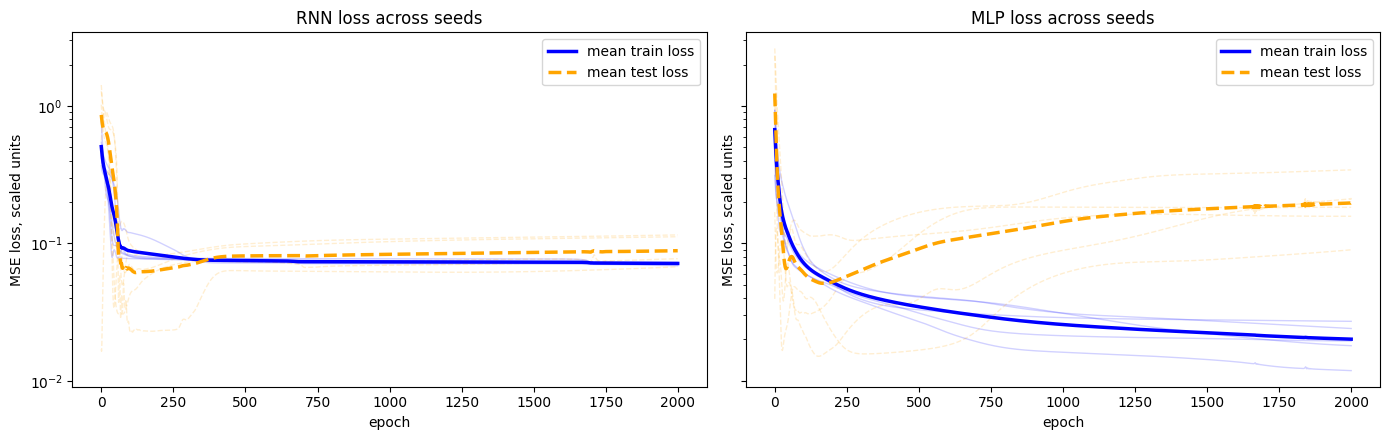

In [330]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for j, arch in enumerate(["rnn", "mlp"]):
    sub = [r for r in results if r["arch"] == arch]

    for r in sub:
        ax[j].plot(r["train_losses"], alpha=0.18, linewidth=1.0,color="blue")
        ax[j].plot(r["test_losses"], "--", alpha=0.18, linewidth=1.0,color="orange")

    # average loss across seeds
    train_mean = np.mean([r["train_losses"] for r in sub], axis=0)
    test_mean  = np.mean([r["test_losses"] for r in sub], axis=0)

    ax[j].plot(train_mean,color="blue", linewidth=2.5, label="mean train loss")
    ax[j].plot(test_mean, "--",color="orange", linewidth=2.5, label="mean test loss")

    ax[j].set_yscale("log")
    ax[j].set_title(f"{arch.upper()} loss across seeds")
    ax[j].set_xlabel("epoch")
    ax[j].set_ylabel("MSE loss, scaled units")
    ax[j].legend()

plt.tight_layout()
plt.show()

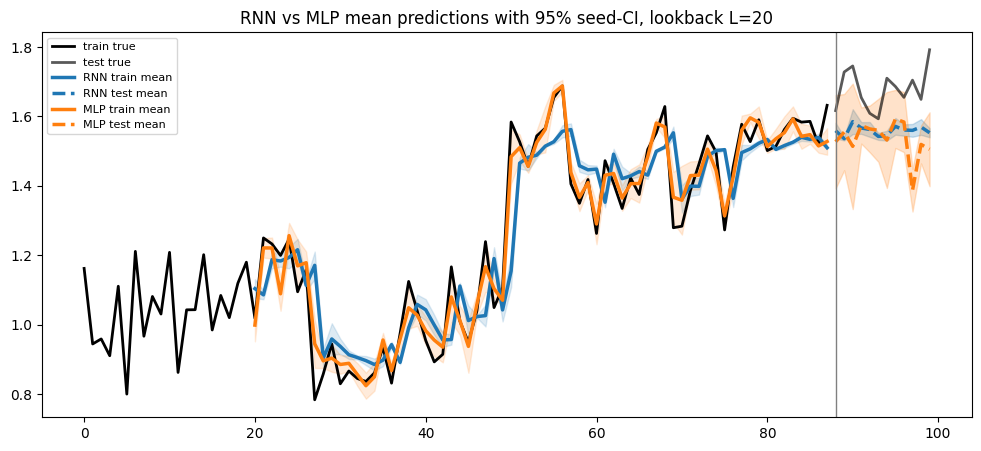

In [331]:
def mean_ci(arrs):
    A = np.stack([a.ravel() for a in arrs], axis=0)
    mean = A.mean(axis=0)
    se = A.std(axis=0, ddof=1) / np.sqrt(A.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi


Ytr_np = y_scaler.inverse_transform(Ytr.numpy()).ravel()
Yte_np = y_scaler.inverse_transform(Yte.numpy()).ravel()

train_idx_old = np.arange(len(Ytr_np))
test_idx_old  = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))

train_idx_seq = np.arange(L, len(Ytr_np))
test_idx_seq  = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))

plt.figure(figsize=(12, 5))

plt.plot(train_idx_old, Ytr_np, color="black", linewidth=2, label="train true")
plt.plot(test_idx_old, Yte_np, color="black", linewidth=2, alpha=0.65, label="test true")

for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    sub = [r for r in results if r["arch"] == arch]

    train_mean, train_lo, train_hi = mean_ci([r["train_pred_np"] for r in sub])
    test_mean, test_lo, test_hi = mean_ci([r["test_pred_np"] for r in sub])

    plt.plot(train_idx_seq, train_mean, color=color, linewidth=2.5, label=f"{arch.upper()} train mean")
    plt.fill_between(train_idx_seq, train_lo, train_hi, color=color, alpha=0.15)

    plt.plot(test_idx_seq, test_mean, color=color, linestyle="--", linewidth=2.5, label=f"{arch.upper()} test mean")
    plt.fill_between(test_idx_seq, test_lo, test_hi, color=color, alpha=0.22)

plt.axvline(len(Ytr_np), color="grey", linewidth=1)
plt.title(f"RNN vs MLP mean predictions with 95% seed-CI, lookback L={L}")
plt.legend(fontsize=8)
plt.show()

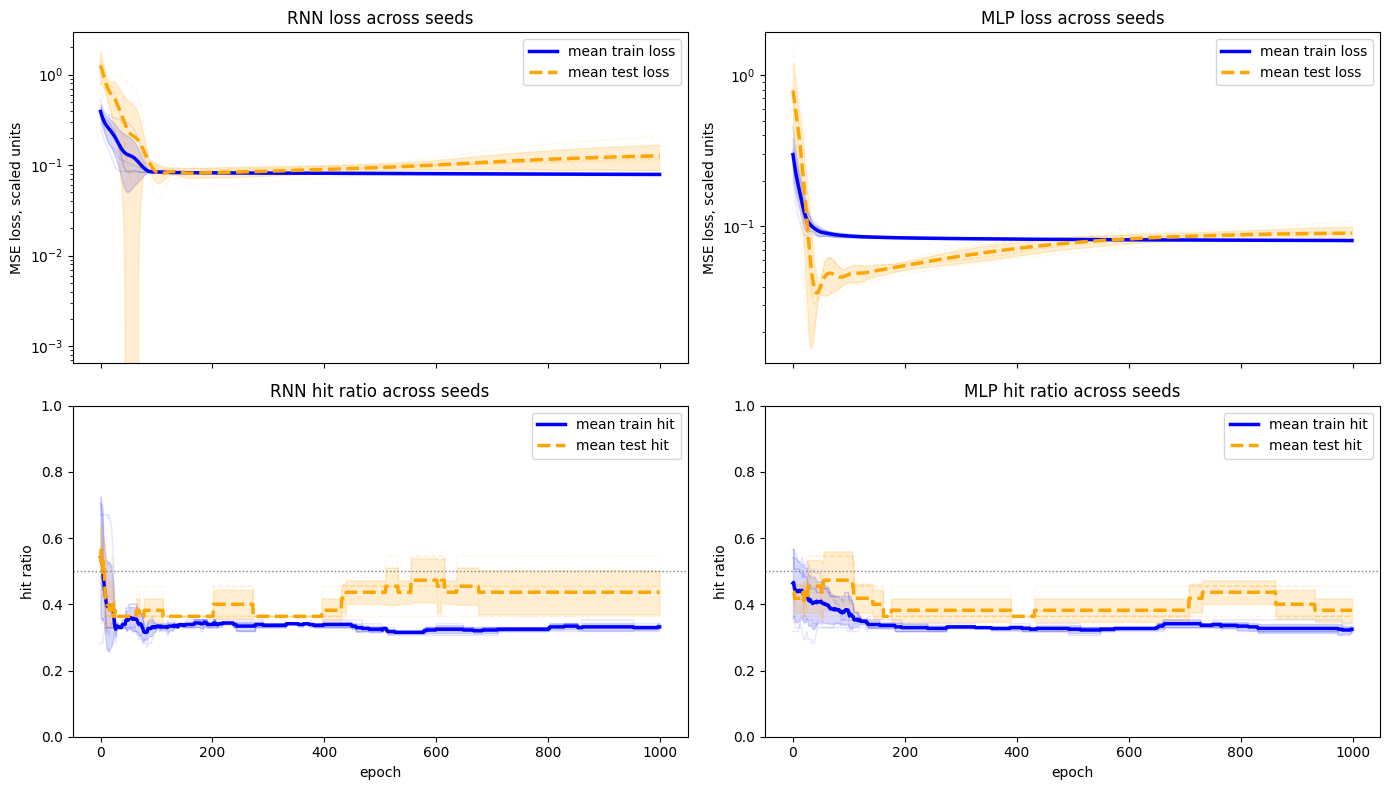

In [323]:
def mean_ci_series(series_list):
    A = np.array(series_list, dtype=float)
    mean = np.nanmean(A, axis=0)
    se = np.nanstd(A, axis=0, ddof=1) / np.sqrt(A.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi


fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for j, arch in enumerate(["rnn", "mlp"]):
    sub = [r for r in results if r["arch"] == arch]
    epochs_idx = np.arange(len(sub[0]["train_losses"]))

    # ---------- losses ----------
    train_mean, train_lo, train_hi = mean_ci_series([r["train_losses"] for r in sub])
    test_mean, test_lo, test_hi = mean_ci_series([r["test_losses"] for r in sub])

    for r in sub:
        ax[0, j].plot(r["train_losses"], alpha=0.10, linewidth=1.0, color="blue")
        ax[0, j].plot(r["test_losses"], "--", alpha=0.10, linewidth=1.0, color="orange")

    ax[0, j].plot(epochs_idx, train_mean, color="blue", linewidth=2.5, label="mean train loss")
    ax[0, j].fill_between(epochs_idx, train_lo, train_hi, color="blue", alpha=0.15)

    ax[0, j].plot(epochs_idx, test_mean, "--", color="orange", linewidth=2.5, label="mean test loss")
    ax[0, j].fill_between(epochs_idx, test_lo, test_hi, color="orange", alpha=0.18)

    ax[0, j].set_yscale("log")
    ax[0, j].set_title(f"{arch.upper()} loss across seeds")
    ax[0, j].set_ylabel("MSE loss, scaled units")
    ax[0, j].legend()

    # ---------- hit ratios ----------
    train_hit_mean, train_hit_lo, train_hit_hi = mean_ci_series([r["train_hits"] for r in sub])
    test_hit_mean, test_hit_lo, test_hit_hi = mean_ci_series([r["test_hits"] for r in sub])

    for r in sub:
        ax[1, j].plot(r["train_hits"], alpha=0.10, linewidth=1.0, color="blue")
        ax[1, j].plot(r["test_hits"], "--", alpha=0.10, linewidth=1.0, color="orange")

    ax[1, j].plot(epochs_idx, train_hit_mean, color="blue", linewidth=2.5, label="mean train hit")
    ax[1, j].fill_between(epochs_idx, train_hit_lo, train_hit_hi, color="blue", alpha=0.15)

    ax[1, j].plot(epochs_idx, test_hit_mean, "--", color="orange", linewidth=2.5, label="mean test hit")
    ax[1, j].fill_between(epochs_idx, test_hit_lo, test_hit_hi, color="orange", alpha=0.18)

    ax[1, j].axhline(0.5, color="grey", linewidth=1, linestyle=":")
    ax[1, j].set_title(f"{arch.upper()} hit ratio across seeds")
    ax[1, j].set_xlabel("epoch")
    ax[1, j].set_ylabel("hit ratio")
    ax[1, j].set_ylim(0, 1)
    ax[1, j].legend()

plt.tight_layout()
plt.show()